In [ ]:
# Step 0: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
print("Libraries imported.")

Libraries imported.


In [ ]:
# Step 1: Load Data
train_df = pd.read_csv('/content/train_.csv')
test_df = pd.read_csv('/content/test_.csv')
pincodes_df = pd.read_csv('/content/pincodes.csv')
print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Pincodes data shape: {pincodes_df.shape}")

print("\nColumns in train_df:")
print(train_df.columns)
print("\nColumns in test_df:")
print(test_df.columns)
print("\nColumns in pincodes_df:")
print(pincodes_df.columns)

print(f"Data Loaded Successfully.")

Train data shape: (1400831, 10)
Test data shape: (399845, 8)
Pincodes data shape: (157126, 11)

Columns in train_df:
Index(['id', 'order_delivered_date', 'courier_partner_id',
       'order_shipped_date', 'account_type_id', 'drop_pin_code',
       'pickup_pin_code', 'quantity', 'account_mode', 'order_delivery_sla'],
      dtype='object')

Columns in test_df:
Index(['id', 'courier_partner_id', 'order_shipped_date', 'account_type_id',
       'drop_pin_code', 'pickup_pin_code', 'quantity', 'account_mode'],
      dtype='object')

Columns in pincodes_df:
Index(['CircleName', 'RegionName', 'DivisionName', 'OfficeName', 'Pincode',
       'OfficeType', 'Delivery', 'District', 'StateName', 'Latitude',
       'Longitude'],
      dtype='object')
Data Loaded Successfully.


<ipython-input-9-59d66e5e2ec1>:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  pincodes_df = pd.read_csv('/content/pincodes.csv')


Target column: order_delivery_sla
Converting train date columns: ['order_delivered_date', 'order_shipped_date']
Converting test date columns: ['order_shipped_date']
Defining essential columns : ['order_delivery_sla', 'order_shipped_date', 'order_delivered_date']
Converting target column 'order_delivery_sla' to numeric/integer.
Filtering out non-positive values in target column 'order_delivery_sla'.
Train data shape after initial cleaning: (1269386, 10)

Target Variable ('order_delivery_sla') Description:
count    1.269386e+06
mean     2.878697e+00
std      1.751735e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      9.100000e+01
Name: order_delivery_sla, dtype: float64


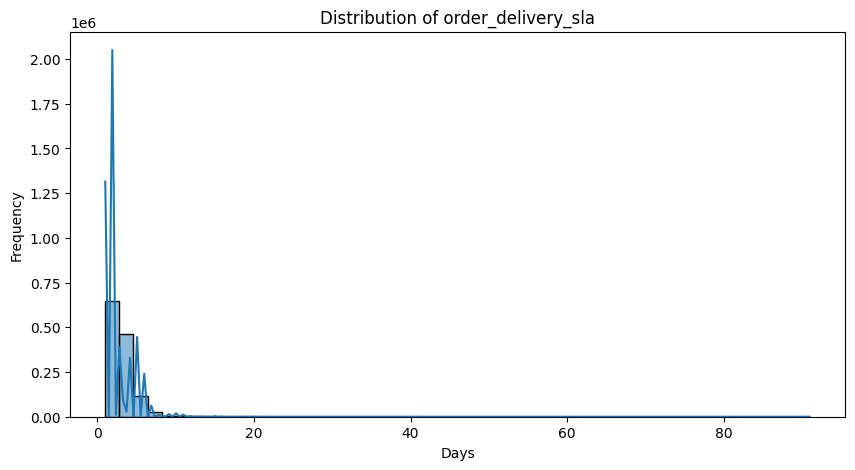

In [ ]:
# Step 2: Define Target Variable & Initial Cleaning


# Target Variable
target_col = 'order_delivery_sla'
print(f"Target column: {target_col}")

# Date Conversions
date_cols_train = ['order_delivered_date', 'order_shipped_date']
print(f"Converting train date columns: {date_cols_train}")

for col in date_cols_train:
      train_df[col] = pd.to_datetime(train_df[col], errors='coerce')

date_cols_test = ['order_shipped_date']
print(f"Converting test date columns: {date_cols_test}")

for col in date_cols_test:
      test_df[col] = pd.to_datetime(test_df[col], errors='coerce')


# Data Cleaning & Target Preparation

essential_cols = [target_col, 'order_shipped_date', 'order_delivered_date']
print(f"Defining essential columns : {essential_cols}")

train_df.dropna(subset=essential_cols, inplace=True)

# Ensure target is numeric and integer
print(f"Converting target column '{target_col}' to numeric/integer.")
train_df[target_col] = pd.to_numeric(train_df[target_col], errors='coerce')
train_df.dropna(subset=[target_col], inplace=True)
train_df[target_col] = train_df[target_col].astype(int)

# Filter out non-positive delivery times
print(f"Filtering out non-positive values in target column '{target_col}'.")
train_df = train_df[train_df[target_col] > 0]
print(f"Train data shape after initial cleaning: {train_df.shape}")

# Basic Stats & Distribution of Target
print(f"\nTarget Variable ('{target_col}') Description:")
print(train_df[target_col].describe())

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(train_df[target_col], bins=50, kde=True)
plt.title(f'Distribution of {target_col}')
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Step 3: Merge Pincode Data

actual_pincode_col_name = 'Pincode'
print(f"Using '{actual_pincode_col_name}' as the pincode column name in pincodes_df.")

# Preparing pincode data (droping duplicates)

initial_pincode_rows = len(pincodes_df)
pincodes_df = pincodes_df.drop_duplicates(subset=[actual_pincode_col_name])
print(f"Dropped {initial_pincode_rows - len(pincodes_df)} duplicate rows based on '{actual_pincode_col_name}'. Pincodes data shape: {pincodes_df.shape}")


# Function to merge pincode details
def merge_pincode_data(df, pincodes_df, actual_pin_col):
    geo_cols_rename = {'StateName': 'state', 'District': 'city', 'Latitude': 'latitude', 'Longitude': 'longitude'}


    # Check which geo columns actually exist in pincodes_df
    available_geo_cols = {k: v for k, v in geo_cols_rename.items() if k in pincodes_df.columns}
    print(f"Available geo columns in pincodes_df for merging: {list(available_geo_cols.keys())}")

    # Merging for pickup pincode
    df = pd.merge(df, pincodes_df[[actual_pin_col] + list(available_geo_cols.keys())],
                  left_on='pickup_pin_code', right_on=actual_pin_col,
                  how='left')

    # Rename merged columns with _pickup suffix
    rename_map_pickup = {k: v + '_pickup' for k, v in available_geo_cols.items()}
    df.rename(columns=rename_map_pickup, inplace=True)
    df.drop(columns=[actual_pin_col], errors='ignore', inplace=True)

    # Merging for drop pincode
    df = pd.merge(df, pincodes_df[[actual_pin_col] + list(available_geo_cols.keys())],
                  left_on='drop_pin_code', right_on=actual_pin_col,
                  how='left')
    # Rename merged columns with _drop suffix
    rename_map_drop = {k: v + '_drop' for k, v in available_geo_cols.items()}
    df.rename(columns=rename_map_drop, inplace=True)
    df.drop(columns=[actual_pin_col], errors='ignore', inplace=True)

    return df

# Merging for both train and test
print("Merging pincode data with train_df...")
train_df = merge_pincode_data(train_df.copy(), pincodes_df, actual_pincode_col_name)
print("Merging pincode data with test_df...")
test_df = merge_pincode_data(test_df.copy(), pincodes_df, actual_pincode_col_name)

print(f"\nTrain data shape after merging pincodes: {train_df.shape}")
print(f"Test data shape after merging pincodes: {test_df.shape}")
print(f"Step 3 finished.")

Using 'Pincode' as the pincode column name in pincodes_df.
Dropped 137826 duplicate rows based on 'Pincode'. Pincodes data shape: (19300, 11)
Merging pincode data with train_df...
Available geo columns in pincodes_df for merging: ['StateName', 'District', 'Latitude', 'Longitude']
Merging pincode data with test_df...
Available geo columns in pincodes_df for merging: ['StateName', 'District', 'Latitude', 'Longitude']

Train data shape after merging pincodes: (1269386, 18)
Test data shape after merging pincodes: (399845, 16)
Step 3 finished.


In [ ]:
# Step 4: Feature Engineering (Highly Minimized)

def engineer_features_minimal(df):
    df_eng = df.copy()
    ship_date_col = 'order_shipped_date'

    # Date Features
    dt_accessor = df_eng[ship_date_col].dt
    df_eng['ship_day_of_week'] = dt_accessor.dayofweek
    df_eng['ship_month'] = dt_accessor.month
    df_eng['ship_week_of_year'] = dt_accessor.isocalendar().week.astype(int)
    df_eng['ship_is_weekend'] = (df_eng['ship_day_of_week'] >= 5).astype(int)

    # Geographic Features
    geo_cols_to_process = [
        'state_pickup', 'state_drop', 'city_pickup', 'city_drop',
        'latitude_pickup', 'longitude_pickup', 'latitude_drop', 'longitude_drop'
    ]
    for col in geo_cols_to_process:
        if col in df_eng:
            is_numeric_geo = ('latitude' in col or 'longitude' in col)
            fill_value = 0.0 if is_numeric_geo else 'Unknown'
            col_data = df_eng[col].fillna(fill_value)

            if is_numeric_geo:
                if isinstance(col_data, pd.Series):
                    df_eng[col] = pd.to_numeric(col_data, errors='coerce').fillna(fill_value)
                else:
                    df_eng[col] = fill_value
            else:
                df_eng[col] = col_data.astype(str)

    # Haversine Distance
    lat_lon_cols = ['latitude_pickup', 'longitude_pickup', 'latitude_drop', 'longitude_drop']
    # Calculating distance
    if all(col in df_eng.columns and pd.api.types.is_numeric_dtype(df_eng[col]) for col in lat_lon_cols):
        pickup_lat_rad, pickup_lon_rad, drop_lat_rad, drop_lon_rad = map(
            np.radians,
            [df_eng['latitude_pickup'], df_eng['longitude_pickup'], df_eng['latitude_drop'], df_eng['longitude_drop']]
        )
        dlon = drop_lon_rad - pickup_lon_rad
        dlat = drop_lat_rad - pickup_lat_rad
        a = np.sin(dlat / 2)**2 + np.cos(pickup_lat_rad) * np.cos(drop_lat_rad) * np.sin(dlon / 2)**2
        c = 2 * np.arcsin(np.sqrt(np.maximum(a, 0)))
        df_eng['haversine_distance_km'] = (c * 6371).fillna(0.0)
    else:
        df_eng['haversine_distance_km'] = 0.0

    # Other Geographic Comparisons & Routes
    df_eng['is_same_state'] = (df_eng['state_pickup'].values == df_eng['state_drop'].values).astype(int) if 'state_pickup' in df_eng else 0
    df_eng['route_state'] = df_eng['state_pickup'].astype(str) + '_to_' + df_eng['state_drop'].astype(str) if 'state_pickup' in df_eng else 'Unknown_to_Unknown'
    df_eng['is_same_city'] = (df_eng['city_pickup'].values == df_eng['city_drop'].values).astype(int) if 'city_pickup' in df_eng else 0

    # Interaction Features
    df_eng['courier_x_drop_state'] = df_eng['courier_partner_id'].astype(str) + '_' + df_eng['state_drop'].astype(str) if 'courier_partner_id' in df_eng else 'Unknown_Unknown'

    # Handle Quantity
    if 'quantity' in df_eng.columns:
        qty_data = df_eng['quantity']
        if isinstance(qty_data, pd.Series):
             median_qty = pd.to_numeric(qty_data, errors='coerce').median()
             if pd.isna(median_qty): median_qty = 1
             df_eng['quantity'] = pd.to_numeric(qty_data, errors='coerce').fillna(median_qty)
        else:
             df_eng['quantity'] = 1
    else:
        df_eng['quantity'] = 1

    return df_eng

# Apply minimized feature engineering function for test and train data
train_df = engineer_features_minimal(train_df)
test_df = engineer_features_minimal(test_df)

print(f"Minimized feature engineering complete. Final shapes - Train: {train_df.shape}, Test: {test_df.shape}")
print("Step 4 finished.")

Minimized feature engineering complete. Final shapes - Train: (1269386, 27), Test: (399845, 25)
Step 4 finished.


In [ ]:
# Step 5: Preprocessing for Modeling


# Define Columns to Exclude these columns will NOT be treated as features
cols_to_exclude = ['id', 'order_delivered_date', 'order_shipped_date', target_col]
cols_to_exclude.extend(['pickup_pin_code', 'drop_pin_code'])

# Identifying Feature Columns
potential_feature_cols = [col for col in train_df.columns if col not in cols_to_exclude and col != target_col]
print(f"Found {len(potential_feature_cols)} potential feature columns initially.")

# Separating Numerical and Categorical Features
categorical_features = []
numerical_features = []
high_cardinality_threshold = 150 # Max unique values for OHE

for col in potential_feature_cols:

    # Checking for numerical types first
    if pd.api.types.is_numeric_dtype(train_df[col]):
        if train_df[col].isnull().any() or test_df[col].isnull().any():
            median_val = train_df[col].median()
        numerical_features.append(col)
    # Treat everything else (object, category, potentially bool) as potential categorical
    else:
        # Converting both train and test to string
        train_df[col] = train_df[col].astype(str)
        test_df[col] = test_df[col].astype(str) # Ensure test is also string

        nunique = train_df[col].nunique(dropna=False)
        if nunique < high_cardinality_threshold:
            categorical_features.append(col)
        else:
             print(f"Skipping high-cardinality categorical feature: {col} ({nunique} unique values)")

print(f"\nIdentified {len(numerical_features)} numerical features.")
print(f"Identified {len(categorical_features)} categorical features for OHE: {categorical_features}")

# One-Hot Encoding
# Useing pandas get_dummies on the identified categorical features
if categorical_features:
    train_df_ohe = pd.get_dummies(train_df, columns=categorical_features, dummy_na=False)
    test_df_ohe = pd.get_dummies(test_df, columns=categorical_features, dummy_na=False)
    print(f"Applied OHE. Shapes after OHE - Train: {train_df_ohe.shape}, Test: {test_df_ohe.shape}")
else:
    train_df_ohe = train_df.copy()
    test_df_ohe = test_df.copy()
    print("No categorical features to encode.")


# Aliging Columns using reindex
all_cols = train_df_ohe.columns.union(test_df_ohe.columns)
train_df_ohe = train_df_ohe.reindex(columns=all_cols, fill_value=0)
test_df_ohe = test_df_ohe.reindex(columns=all_cols, fill_value=0)


# Defineing Final Feature List
final_features = numerical_features[:]

# Adding OHE columns
for cat_col in categorical_features:
     ohe_cols_for_cat = [col for col in train_df_ohe.columns if col.startswith(f"{cat_col}_")]
     final_features.extend(ohe_cols_for_cat)

# Removeing duplicates
final_features = sorted(list(set(final_features)))

# Final check: Ensure all features in the list actually exist in the aligned df
final_features = [f for f in final_features if f in train_df_ohe.columns]

# Assigning to the global 'features' variable
features = final_features
print(f"Columns aligned. Final features count: {len(features)}")
print("Step 5 finished.")

Found 21 potential feature columns initially.
Skipping high-cardinality categorical feature: city_drop (709 unique values)
Skipping high-cardinality categorical feature: route_state (166 unique values)
Skipping high-cardinality categorical feature: courier_x_drop_state (167 unique values)

Identified 14 numerical features.
Identified 4 categorical features for OHE: ['account_mode', 'state_pickup', 'city_pickup', 'state_drop']
Applied OHE. Shapes after OHE - Train: (1269386, 72), Test: (399845, 69)
Columns aligned. Final features count: 63
Step 5 finished.


In [ ]:
# Step 6: Model Training and Validation

# Createing X and y using the features

X = train_df_ohe[features]
y = train_df_ohe[target_col]

# Also checking columns exist in test data for consistency
missing_in_test = [f for f in features if f not in test_df_ohe.columns]

# Time-based Split
ship_date_col = 'order_shipped_date'


train_df_ohe_sorted = train_df_ohe.sort_values(ship_date_col)
X_sorted = train_df_ohe_sorted[features]
y_sorted = train_df_ohe_sorted[target_col]

validation_duration = pd.Timedelta(weeks=3)

split_date = train_df_ohe_sorted[ship_date_col].max() - validation_duration
train_indices = train_df_ohe_sorted[train_df_ohe_sorted[ship_date_col] < split_date].index
val_indices = train_df_ohe_sorted[train_df_ohe_sorted[ship_date_col] >= split_date].index

# # Fallback if validation set is empty or too small (adjust threshold if needed)
# min_val_samples = 100 # Define minimum validation samples
# if len(val_indices) < min_val_samples:
#      print(f"Warning: Time-split resulted in < {min_val_samples} validation samples. Using 85/15 split.")
#      split_index = int(len(X_sorted) * 0.85)
#      # Ensure split_index doesn't lead to empty sets
#      split_index = max(1, min(split_index, len(X_sorted)-1))
#      train_indices = X_sorted.index[:split_index]
#      val_indices = X_sorted.index[split_index:]

# if len(train_indices) == 0 or len(val_indices) == 0:
#      print("FATAL ERROR: Data split resulted in empty train or validation set.")

X_train, X_val = X_sorted.loc[train_indices], X_sorted.loc[val_indices]
y_train, y_val = y_sorted.loc[train_indices], y_sorted.loc[val_indices]

# Ensureing validation set has same columns as training set
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)


# Pre-computation Checking for Non-Numeric Data

object_columns_train = X_train.select_dtypes(include=['object']).columns
object_columns_val = X_val.select_dtypes(include=['object']).columns

# Training XGBoost Model
xgb_params = {
    'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'eta': 0.05,
    'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'n_estimators': 1000, 'seed': 42, 'nthread': -1, 'tree_method': 'hist',
    'early_stopping_rounds': 100
}
model = xgb.XGBRegressor(**xgb_params)

# Convert data to NumPy arrays

X_train_np = X_train.values
y_train_np = y_train.values
X_val_np = X_val.values
y_val_np = y_val.values



eval_set = [(X_val_np, y_val_np)]

# Train the model
model.fit(X_train_np, y_train_np, eval_set=eval_set, verbose=False)

print("Model training complete.")


# Evaluate on Validation Set

val_preds = model.predict(X_val_np)



# Post-process predictions
val_preds = np.round(val_preds).astype(int)
val_preds = np.maximum(1, val_preds)

# Ensure y_val is numpy for calculations
y_val_for_calc = y_val.values if isinstance(y_val, pd.Series) else y_val


# Calculate Evaluation Metrics
tolerance = 1
accuracy_within_tolerance = np.mean(np.abs(y_val_for_calc - val_preds) <= tolerance) * 100
rmse_val = np.sqrt(mean_squared_error(y_val_for_calc, val_preds))
rmse_within_sla = rmse_val
mae_val = mean_absolute_error(y_val_for_calc, val_preds)
r2_val = r2_score(y_val_for_calc, val_preds)
medae_val = median_absolute_error(y_val_for_calc, val_preds)
bias_val = np.mean(y_val_for_calc - val_preds)
print(f"Accuracy (+/- {tolerance} day): {accuracy_within_tolerance:.2f}%")
print(f"Overall RMSE: {rmse_val:.4f}")
print(f"RMSE (within promised SLA interpretation): {rmse_within_sla:.4f}")
print(f"MAE: {mae_val:.4f} days")
print(f"R-squared: {r2_val:.4f}")
print(f"Median Absolute Error: {medae_val:.4f} days")
print(f"Mean Error (Bias): {bias_val:.4f} days")
print("--- End Validation Metrics ---")

print("Step 6 finished.")

Model training complete.
Accuracy (+/- 1 day): 91.87%
Overall RMSE: 1.1014
RMSE (within promised SLA interpretation): 1.1014
MAE: 0.6435 days
R-squared: 0.5401
Median Absolute Error: 1.0000 days
Mean Error (Bias): -0.0261 days
--- End Validation Metrics ---
Step 6 finished.


In [ ]:
# Step 7: Final Prediction on Test Set

# Retrain on Full Training Data

best_iteration = getattr(model, 'best_iteration', None)

final_params = xgb_params.copy()
final_params['n_estimators'] = best_iteration
final_params.pop('early_stopping_rounds', None)

final_model = xgb.XGBRegressor(**final_params)

# Converting full training data to NumPy
X_sorted_np = X_sorted.values
y_sorted_np = y_sorted.values
print("Conversion successful.")
final_model.fit(X_sorted_np, y_sorted_np, verbose=False)
print("Final model trained.")

# Predicting on Test Set
X_test = test_df_ohe[features]
X_test = X_test.reindex(columns=X_sorted.columns, fill_value=0)
print(f"Test data shape for prediction: {X_test.shape}")

# Converting test data to NumPy for prediction

X_test_np = X_test.values


print("Making predictions on the test set")
test_preds = final_model.predict(X_test_np)

# Post-process predictions
test_preds = np.round(test_preds).astype(int)
test_preds = np.maximum(1, test_preds)
print("Predictions generated and post-processed.")

# Createing Submission File

submission_df = pd.DataFrame({'id': test_df_ohe['id'], 'predicted_exact_sla': test_preds})

print("\nSample Submission:")
print(submission_df.head())

# Save the submission file
submission_filename = 'submission_xgboost.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"\nSubmission file '{submission_filename}' created successfully.")
print("\n!!..Project Execution Finished..!!")

Conversion successful.
Final model trained.
Test data shape for prediction: (399845, 63)
Making predictions on the test set
Predictions generated and post-processed.

Sample Submission:
          id  predicted_exact_sla
0  428365149                    2
1  428365152                    2
2  428365154                    2
3  428365156                    1
4  428365161                    2

Submission file 'submission_xgboost.csv' created successfully.

!!..Project Execution Finished..!!
